## 股息单因子回测

预期股息率（TTM）：最近365个自然日div_pre_tax和 / **不复权**市场价格，计入日期区间所有announce_date在这之间的总分红；

~~静态股息率：上一财年总div_pre_tax和 / **不复权**市场价格，计入ex_date在当前日期之前且div_year为当前日期上一年的总分红；~~

动态股息率（TTM）：最近365个自然日div_pre_tax和 / **不复权**市场价格，计入日期区间所有ex_date在这之间的总分红；

~~div_after_tax~~ div_pre_tax ：税前股息反映的是公司真实分红能力，税后股息只反映单个投资者的到手收益，前者更适合做因子/估值。

使用不复权价格的优点：不会像使用复权那样股息率失真

Expected Dividend Yield (TTM):
Sum of div_pre_tax over the most recent 365 calendar days / non-adjusted market price.
Includes total dividends whose announce_date falls within the date range.
Static Dividend Yield:
Total div_pre_tax of the previous fiscal year / non-adjusted market price.
Includes total dividends whose ex_date is before the current date and div_year equals the year prior to the current date.
**Dynamic Dividend Yield (TTM)**:
Sum of div_pre_tax over the most recent 365 calendar days / non-adjusted market price.
Includes total dividends whose ex_date falls within the date range.
div_pre_tax (not div_after_tax):
Pre-tax dividend reflects a company’s true profitability and cash distribution capacity,
while after-tax dividend only represents individual investors’ actual received income.
The former is more suitable for factor construction and valuation analysis.

In [47]:
import pandas as pd
div_factor_dt=pd.read_parquet("data/dividend_factor.parquet")
div_factor_dt.head()

,stock_code,trade_date,expected_div_yield,static_div_yield,dynamic_div_yield,year,industry_name
0,000001.SZ,2013-01-04,0.0,0.0,0.0,2013,银行
1,000001.SZ,2013-01-07,0.0,0.0,0.0,2013,银行
2,000001.SZ,2013-01-08,0.0,0.0,0.0,2013,银行
3,000001.SZ,2013-01-09,0.0,0.0,0.0,2013,银行
4,000001.SZ,2013-01-10,0.0,0.0,0.0,2013,银行


In [ ]:
temp=pd.read_parquet("data/ref_data/ETF_hold_510300.SH.parquet")
temp=temp[temp['end_date']=='2018-06-30']
temp.head()

,fund_code,end_date,stock_code,index_value,report_year,report_type


由于给定的数据中缺少早期数据，采用的回测方法是早期全样本，后期沪深300.因为沪深300股票数量较少，采用每个行业TOP1/2股票

In [55]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import os
from scipy.stats.mstats import winsorize

CONFIG = {
    "TOP_N": 2,
    "BOTTOM_N": 2,
    "FACTOR_COLUMN": "dynamic_div_yield",
    "USE_WINSORIZE": False,
    "WINSORIZE_LIMITS": (0.01, 0.01),
    "STANDARDIZE_BY_INDUSTRY": False,
    "DIVIDEND_FACTOR_FILE": 'data/dividend_factor.parquet',
    "FUND_FILE": 'data/ref_data/ETF_hold_510300.SH.parquet',
    "SIGNAL_SAVE_PATH": 'records/industry_selection.parquet'
}

def generate_industry_signals(config):
    os.makedirs(os.path.dirname(config['SIGNAL_SAVE_PATH']), exist_ok=True)
    print("=" * 60)
    print("行业分层选股信号生成 (每个行业 Top{} / Bottom{})".format(config['TOP_N'], config['BOTTOM_N']))
    print(f"因子列: {config['FACTOR_COLUMN']}")
    print(f"行业内标准化: {'开启' if config['STANDARDIZE_BY_INDUSTRY'] else '关闭'}")
    print("=" * 60)

    # ----------------------------
    # 1. 加载数据
    # ----------------------------
    dividend_factor = pd.read_parquet(config["DIVIDEND_FACTOR_FILE"])
    fund_df = pd.read_parquet(config["FUND_FILE"])

    # 剔除行业名缺失的行
    dividend_factor = dividend_factor.dropna(subset=['industry_name'])

    # 统一日期格式
    dividend_factor['trade_date'] = pd.to_datetime(dividend_factor['trade_date'])
    fund_df = fund_df.rename(columns={'end_date': 'report_end_date'})
    fund_df['report_end_date'] = pd.to_datetime(fund_df['report_end_date'])

    # 判断是否需要成分股过滤
    if fund_df.empty:
        print("⚠️ 警告：基金持仓文件为空，将使用全部股票（不进行成分股过滤）")
        use_all_stocks = True
        fund_holdings = pd.DataFrame()  # 占位
    else:
        use_all_stocks = False
        def get_position_valid_period(row):
            year = row['report_year']
            if row['report_type'] == '中报':
                start_date = pd.to_datetime(f'{year}-01-01')
                end_date = pd.to_datetime(f'{year}-06-30')
            elif row['report_type'] == '年报':
                start_date = pd.to_datetime(f'{year}-07-01')
                end_date = pd.to_datetime(f'{year}-12-31')
            else:
                start_date = end_date = row['report_end_date']
            return pd.Series([start_date, end_date], index=['pos_start_date', 'pos_end_date'])

        fund_df[['pos_start_date', 'pos_end_date']] = fund_df.apply(get_position_valid_period, axis=1)
        fund_holdings = fund_df[['stock_code', 'pos_start_date', 'pos_end_date']].drop_duplicates()

        # 过滤出历史上所有出现过的沪深300成分股（初步筛选）
        csi_300_stocks = fund_holdings['stock_code'].unique()
        dividend_factor = dividend_factor[dividend_factor['stock_code'].isin(csi_300_stocks)]

    # 检查因子列
    factor_col = config["FACTOR_COLUMN"]
    if factor_col not in dividend_factor.columns:
        raise KeyError(f"因子文件缺少列 '{factor_col}'，可用列：{dividend_factor.columns.tolist()}")

    # ----------------------------
    # 2. 缩尾处理（可选）
    # ----------------------------
    if config['USE_WINSORIZE']:
        print("执行因子缩尾处理...")
        dividend_factor[factor_col] = winsorize(
            dividend_factor[factor_col].values,
            limits=config['WINSORIZE_LIMITS'],
            inclusive=(True, True)
        )

    # ----------------------------
    # 3. 行业内标准化（可选）
    # ----------------------------
    if config['STANDARDIZE_BY_INDUSTRY']:
        print("计算行业内截面标准化因子...")
        dividend_factor['factor_std'] = dividend_factor.groupby(['trade_date', 'industry_name'])[factor_col].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0
        )
        score_col = 'factor_std'
    else:
        score_col = factor_col

    # ----------------------------
    # 4. 按日、按行业生成信号
    # ----------------------------
    all_signals = []
    unique_dates = sorted(dividend_factor['trade_date'].unique())

    for trade_date in tqdm(unique_dates, desc="处理交易日"):
        daily = dividend_factor[dividend_factor['trade_date'] == trade_date].copy()

        if daily.empty:
            continue

        # ---------- 获取当日有效成分股 ----------
        if use_all_stocks:
            valid_codes = daily['stock_code'].unique()
        else:
            valid_codes = fund_holdings[
                (fund_holdings['pos_start_date'] <= trade_date) &
                (fund_holdings['pos_end_date'] >= trade_date)
            ]['stock_code'].tolist()
            if len(valid_codes) == 0:
                valid_codes = daily['stock_code'].unique()

        daily = daily[daily['stock_code'].isin(valid_codes)]
        daily = daily.dropna(subset=[score_col])

        if daily.empty:
            continue

        daily['signal'] = 'none'

        for industry, group in daily.groupby('industry_name'):
            if len(group) == 0:
                continue

            group_sorted = group.sort_values(score_col, ascending=False)
            n_stocks = len(group_sorted)
            top_n = min(config['TOP_N'], n_stocks)
            bottom_n = min(config['BOTTOM_N'], n_stocks)

            indices = group_sorted.index

            if top_n > 0:
                long_indices = indices[:top_n]
                daily.loc[long_indices, 'signal'] = 'long'

            remaining_indices = indices[top_n:]
            if bottom_n > 0 and len(remaining_indices) > 0:
                short_indices = remaining_indices[-min(bottom_n, len(remaining_indices)):]
                daily.loc[short_indices, 'signal'] = 'short'

        result = daily[['trade_date', 'stock_code', 'industry_name', score_col, 'signal']].copy()
        result.rename(columns={score_col: 'factor_value'}, inplace=True)
        all_signals.append(result)

    if not all_signals:
        raise ValueError("没有生成任何信号，请检查数据")

    signal_df = pd.concat(all_signals, ignore_index=True)

    # ----------------------------
    # 5. 保存结果
    # ----------------------------
    signal_df.to_parquet(config['SIGNAL_SAVE_PATH'], index=False)
    print(f"\n信号文件已保存至：{config['SIGNAL_SAVE_PATH']}")
    print(f"共 {signal_df['trade_date'].nunique()} 个交易日，{len(signal_df)} 条记录")
    print("\n信号分布（总体）：")
    print(signal_df['signal'].value_counts())
    print("\n各行业信号分布示例（前5个行业）：")
    industry_stats = signal_df.groupby(['industry_name', 'signal']).size().unstack(fill_value=0)
    print(industry_stats.head())

    return signal_df

if __name__ == "__main__":
    signals = generate_industry_signals(CONFIG)

行业分层选股信号生成 (每个行业 Top2 / Bottom2)
因子列: dynamic_div_yield
行业内标准化: 关闭


处理交易日: 100%|██████████| 3134/3134 [01:25<00:00, 36.49it/s]



信号文件已保存至：records/industry_selection.parquet
共 3134 个交易日，1299261 条记录

信号分布（总体）：
signal
none     950023
long     181958
short    167280
Name: count, dtype: int64

各行业信号分布示例（前5个行业）：
signal         long    none  short
industry_name                     
交通运输           6268   41377   6268
传媒             6268   16834   5909
公用事业           6268   34497   6268
农林牧渔           6268   15638   6268
医药生物           6268  105126   6268


In [65]:
import warnings
from util import *

warnings.filterwarnings("ignore")

# ===================== 红利策略 全多头回测配置 =====================
CONFIG = {
    "INITIAL_CASH": 1_000_000,       # 初始资金
    "START_DATE": "2016-07-01",      # 【可调节】回测开始日期
    "END_DATE": "2025-06-30",        # 【可调节】回测结束日期
    "REBALANCE_FREQ": 5,             # 【可调节】调仓频率（每N个选股日）
    "PRICE_FILE": "data/eod_prices.parquet",    # 价格文件路径
    "SELECTION_FILE": "records/industry_selection.parquet", # 红利选股文件
    "TRANSACTION_FEE": 0.001         # 【可调节】交易手续费（0.1%）
}

# ===================== 执行红利策略回测 =====================
portfolio_ser, benchmark_ser, metrics = backtest_long_only(
    initial_cash=CONFIG["INITIAL_CASH"],
    start_date=CONFIG["START_DATE"],
    end_date=CONFIG["END_DATE"],
    rebalance_freq=CONFIG["REBALANCE_FREQ"],
    price_file=CONFIG["PRICE_FILE"],
    selection_file=CONFIG["SELECTION_FILE"],
    transaction_fee_rate=CONFIG["TRANSACTION_FEE"]
)

# ===================== 输出绩效指标 =====================
print("\n==================== 沪深300红利策略 绩效指标 ====================")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# ===================== 绘制回测图表 =====================
plot_results(
    portfolio_values=portfolio_ser,
    benchmark_values=benchmark_ser,
    title=f'沪深300红利策略 | 每{CONFIG["REBALANCE_FREQ"]}日调仓 | 手续费{CONFIG["TRANSACTION_FEE"]*100:.1f}%',
    plot_excess=True
)

Loading data...
Number of rebalance dates: 437

=== 调仓日期：2016-07-01 ===
目标股票数：59 | 总资产：1000000.00 | 每只目标市值：16949.15
实际交易总额：1000000.00 | 手续费：1000.00 | 剩余现金：-1000.00

=== 调仓日期：2016-07-08 ===
目标股票数：59 | 总资产：1027907.68 | 每只目标市值：17422.16
实际交易总额：299696.94 | 手续费：299.70 | 剩余现金：-299.70

=== 调仓日期：2016-07-15 ===
目标股票数：59 | 总资产：1059743.71 | 每只目标市值：17961.76
实际交易总额：166405.26 | 手续费：166.41 | 剩余现金：-166.41

=== 调仓日期：2016-07-22 ===
目标股票数：59 | 总资产：1044936.05 | 每只目标市值：17710.78
实际交易总额：262984.68 | 手续费：262.98 | 剩余现金：-262.98

=== 调仓日期：2016-07-29 ===
目标股票数：59 | 总资产：1042591.97 | 每只目标市值：17671.05
实际交易总额：313521.48 | 手续费：313.52 | 剩余现金：-313.52

=== 调仓日期：2016-08-05 ===
目标股票数：59 | 总资产：1038987.92 | 每只目标市值：17609.96
实际交易总额：123602.05 | 手续费：123.60 | 剩余现金：-123.60

=== 调仓日期：2016-08-12 ===
目标股票数：59 | 总资产：1064450.81 | 每只目标市值：18041.54
实际交易总额：166490.69 | 手续费：166.49 | 剩余现金：-166.49

=== 调仓日期：2016-08-19 ===
目标股票数：59 | 总资产：1101535.88 | 每只目标市值：18670.10
实际交易总额：220248.82 | 手续费：220.25 | 剩余现金：-220.25

=== 调仓日期：2016-08-26 ===
目标股票数：59 | 总资

## 单因子回测稳健性，检验不同时间子样本的策略表现

In [58]:
import warnings
from util import *

warnings.filterwarnings("ignore")

# ===================== 红利策略 全多头回测配置 =====================
CONFIG = {
    "INITIAL_CASH": 1_000_000,       # 初始资金
    "START_DATE": "2016-07-01",      # 【可调节】回测开始日期
    "END_DATE": "2018-06-30",        # 【可调节】回测结束日期
    "REBALANCE_FREQ": 5,             # 【可调节】调仓频率（每N个选股日）
    "PRICE_FILE": "data/eod_prices.parquet",    # 价格文件路径
    "SELECTION_FILE": "records/industry_selection.parquet", # 红利选股文件
    "TRANSACTION_FEE": 0.001         # 【可调节】交易手续费（0.1%）
}

# ===================== 执行红利策略回测 =====================
portfolio_ser, benchmark_ser, metrics = backtest_long_only(
    initial_cash=CONFIG["INITIAL_CASH"],
    start_date=CONFIG["START_DATE"],
    end_date=CONFIG["END_DATE"],
    rebalance_freq=CONFIG["REBALANCE_FREQ"],
    price_file=CONFIG["PRICE_FILE"],
    selection_file=CONFIG["SELECTION_FILE"],
    transaction_fee_rate=CONFIG["TRANSACTION_FEE"]
)

# ===================== 输出绩效指标 =====================
print("\n==================== 沪深300红利策略 绩效指标 ====================")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# ===================== 绘制回测图表 =====================
plot_results(
    portfolio_values=portfolio_ser,
    benchmark_values=benchmark_ser,
    title=f'沪深300红利策略 | 每{CONFIG["REBALANCE_FREQ"]}日调仓 | 手续费{CONFIG["TRANSACTION_FEE"]*100:.1f}%',
    plot_excess=True
)

Loading data...
Number of rebalance dates: 98

=== 调仓日期：2016-07-01 ===
目标股票数：59 | 总资产：1000000.00 | 每只目标市值：16949.15
实际交易总额：1000000.00 | 手续费：1000.00 | 剩余现金：-1000.00

=== 调仓日期：2016-07-08 ===
目标股票数：59 | 总资产：1027907.68 | 每只目标市值：17422.16
实际交易总额：299696.94 | 手续费：299.70 | 剩余现金：-299.70

=== 调仓日期：2016-07-15 ===
目标股票数：59 | 总资产：1059743.71 | 每只目标市值：17961.76
实际交易总额：166405.26 | 手续费：166.41 | 剩余现金：-166.41

=== 调仓日期：2016-07-22 ===
目标股票数：59 | 总资产：1044936.05 | 每只目标市值：17710.78
实际交易总额：262984.68 | 手续费：262.98 | 剩余现金：-262.98

=== 调仓日期：2016-07-29 ===
目标股票数：59 | 总资产：1042591.97 | 每只目标市值：17671.05
实际交易总额：313521.48 | 手续费：313.52 | 剩余现金：-313.52

=== 调仓日期：2016-08-05 ===
目标股票数：59 | 总资产：1038987.92 | 每只目标市值：17609.96
实际交易总额：123602.05 | 手续费：123.60 | 剩余现金：-123.60

=== 调仓日期：2016-08-12 ===
目标股票数：59 | 总资产：1064450.81 | 每只目标市值：18041.54
实际交易总额：166490.69 | 手续费：166.49 | 剩余现金：-166.49

=== 调仓日期：2016-08-19 ===
目标股票数：59 | 总资产：1101535.88 | 每只目标市值：18670.10
实际交易总额：220248.82 | 手续费：220.25 | 剩余现金：-220.25

=== 调仓日期：2016-08-26 ===
目标股票数：59 | 总资产

In [61]:
import warnings
from util import *

warnings.filterwarnings("ignore")

# ===================== 红利策略 全多头回测配置 =====================
CONFIG = {
    "INITIAL_CASH": 1_000_000,       # 初始资金
    "START_DATE": "2018-07-01",      # 【可调节】回测开始日期
    "END_DATE": "2020-06-30",        # 【可调节】回测结束日期
    "REBALANCE_FREQ": 5,             # 【可调节】调仓频率（每N个选股日）
    "PRICE_FILE": "data/eod_prices.parquet",    # 价格文件路径
    "SELECTION_FILE": "records/industry_selection.parquet", # 红利选股文件
    "TRANSACTION_FEE": 0.001         # 【可调节】交易手续费（0.1%）
}

# ===================== 执行红利策略回测 =====================
portfolio_ser, benchmark_ser, metrics = backtest_long_only(
    initial_cash=CONFIG["INITIAL_CASH"],
    start_date=CONFIG["START_DATE"],
    end_date=CONFIG["END_DATE"],
    rebalance_freq=CONFIG["REBALANCE_FREQ"],
    price_file=CONFIG["PRICE_FILE"],
    selection_file=CONFIG["SELECTION_FILE"],
    transaction_fee_rate=CONFIG["TRANSACTION_FEE"]
)

# ===================== 输出绩效指标 =====================
print("\n==================== 沪深300红利策略 绩效指标 ====================")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# ===================== 绘制回测图表 =====================
plot_results(
    portfolio_values=portfolio_ser,
    benchmark_values=benchmark_ser,
    title=f'沪深300红利策略 | 每{CONFIG["REBALANCE_FREQ"]}日调仓 | 手续费{CONFIG["TRANSACTION_FEE"]*100:.1f}%',
    plot_excess=True
)

Loading data...
Number of rebalance dates: 97

=== 调仓日期：2018-07-02 ===
目标股票数：60 | 总资产：1000000.00 | 每只目标市值：16666.67
实际交易总额：1000000.00 | 手续费：1000.00 | 剩余现金：-1000.00

=== 调仓日期：2018-07-09 ===
目标股票数：60 | 总资产：1008712.09 | 每只目标市值：16811.87
实际交易总额：393457.02 | 手续费：393.46 | 剩余现金：-393.46

=== 调仓日期：2018-07-16 ===
目标股票数：60 | 总资产：1020332.16 | 每只目标市值：17005.54
实际交易总额：295677.28 | 手续费：295.68 | 剩余现金：-295.68

=== 调仓日期：2018-07-23 ===
目标股票数：60 | 总资产：1038792.15 | 每只目标市值：17313.20
实际交易总额：539225.77 | 手续费：539.23 | 剩余现金：-539.23

=== 调仓日期：2018-07-30 ===
目标股票数：60 | 总资产：1043975.78 | 每只目标市值：17399.60
实际交易总额：232766.53 | 手续费：232.77 | 剩余现金：-232.77

=== 调仓日期：2018-08-06 ===
目标股票数：60 | 总资产：971105.00 | 每只目标市值：16185.08
实际交易总额：223258.67 | 手续费：223.26 | 剩余现金：-223.26

=== 调仓日期：2018-08-13 ===
目标股票数：60 | 总资产：1011052.61 | 每只目标市值：16850.88
实际交易总额：291837.48 | 手续费：291.84 | 剩余现金：-291.84

=== 调仓日期：2018-08-20 ===
目标股票数：60 | 总资产：971845.25 | 每只目标市值：16197.42
实际交易总额：181866.32 | 手续费：181.87 | 剩余现金：-181.87

=== 调仓日期：2018-08-27 ===
目标股票数：60 | 总资产：1

In [62]:
import warnings
from util import *

warnings.filterwarnings("ignore")

# ===================== 红利策略 全多头回测配置 =====================
CONFIG = {
    "INITIAL_CASH": 1_000_000,       # 初始资金
    "START_DATE": "2020-07-01",      # 【可调节】回测开始日期
    "END_DATE": "2022-06-30",        # 【可调节】回测结束日期
    "REBALANCE_FREQ": 5,             # 【可调节】调仓频率（每N个选股日）
    "PRICE_FILE": "data/eod_prices.parquet",    # 价格文件路径
    "SELECTION_FILE": "records/industry_selection.parquet", # 红利选股文件
    "TRANSACTION_FEE": 0.001         # 【可调节】交易手续费（0.1%）
}

# ===================== 执行红利策略回测 =====================
portfolio_ser, benchmark_ser, metrics = backtest_long_only(
    initial_cash=CONFIG["INITIAL_CASH"],
    start_date=CONFIG["START_DATE"],
    end_date=CONFIG["END_DATE"],
    rebalance_freq=CONFIG["REBALANCE_FREQ"],
    price_file=CONFIG["PRICE_FILE"],
    selection_file=CONFIG["SELECTION_FILE"],
    transaction_fee_rate=CONFIG["TRANSACTION_FEE"]
)

# ===================== 输出绩效指标 =====================
print("\n==================== 沪深300红利策略 绩效指标 ====================")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# ===================== 绘制回测图表 =====================
plot_results(
    portfolio_values=portfolio_ser,
    benchmark_values=benchmark_ser,
    title=f'沪深300红利策略 | 每{CONFIG["REBALANCE_FREQ"]}日调仓 | 手续费{CONFIG["TRANSACTION_FEE"]*100:.1f}%',
    plot_excess=True
)

Loading data...
Number of rebalance dates: 98

=== 调仓日期：2020-07-01 ===
目标股票数：61 | 总资产：1000000.00 | 每只目标市值：16393.44
实际交易总额：1000000.00 | 手续费：1000.00 | 剩余现金：-1000.00

=== 调仓日期：2020-07-08 ===
目标股票数：61 | 总资产：1109586.12 | 每只目标市值：18189.94
实际交易总额：346357.50 | 手续费：346.36 | 剩余现金：-346.36

=== 调仓日期：2020-07-15 ===
目标股票数：61 | 总资产：1117171.89 | 每只目标市值：18314.29
实际交易总额：436729.36 | 手续费：436.73 | 剩余现金：-436.73

=== 调仓日期：2020-07-22 ===
目标股票数：61 | 总资产：1124633.85 | 每只目标市值：18436.62
实际交易总额：291207.15 | 手续费：291.21 | 剩余现金：-291.21

=== 调仓日期：2020-07-29 ===
目标股票数：61 | 总资产：1114607.25 | 每只目标市值：18272.25
实际交易总额：192992.77 | 手续费：192.99 | 剩余现金：-192.99

=== 调仓日期：2020-08-05 ===
目标股票数：61 | 总资产：1153932.84 | 每只目标市值：18916.93
实际交易总额：271081.40 | 手续费：271.08 | 剩余现金：-271.08

=== 调仓日期：2020-08-12 ===
目标股票数：61 | 总资产：1134763.82 | 每只目标市值：18602.69
实际交易总额：261844.64 | 手续费：261.84 | 剩余现金：-261.84

=== 调仓日期：2020-08-19 ===
目标股票数：61 | 总资产：1162046.99 | 每只目标市值：19049.95
实际交易总额：178998.75 | 手续费：179.00 | 剩余现金：-179.00

=== 调仓日期：2020-08-26 ===
目标股票数：61 | 总资产

In [63]:
import warnings
from util import *

warnings.filterwarnings("ignore")

# ===================== 红利策略 全多头回测配置 =====================
CONFIG = {
    "INITIAL_CASH": 1_000_000,       # 初始资金
    "START_DATE": "2022-07-01",      # 【可调节】回测开始日期
    "END_DATE": "2024-06-30",        # 【可调节】回测结束日期
    "REBALANCE_FREQ": 5,             # 【可调节】调仓频率（每N个选股日）
    "PRICE_FILE": "data/eod_prices.parquet",    # 价格文件路径
    "SELECTION_FILE": "records/industry_selection.parquet", # 红利选股文件
    "TRANSACTION_FEE": 0.001         # 【可调节】交易手续费（0.1%）
}

# ===================== 执行红利策略回测 =====================
portfolio_ser, benchmark_ser, metrics = backtest_long_only(
    initial_cash=CONFIG["INITIAL_CASH"],
    start_date=CONFIG["START_DATE"],
    end_date=CONFIG["END_DATE"],
    rebalance_freq=CONFIG["REBALANCE_FREQ"],
    price_file=CONFIG["PRICE_FILE"],
    selection_file=CONFIG["SELECTION_FILE"],
    transaction_fee_rate=CONFIG["TRANSACTION_FEE"]
)

# ===================== 输出绩效指标 =====================
print("\n==================== 沪深300红利策略 绩效指标 ====================")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# ===================== 绘制回测图表 =====================
plot_results(
    portfolio_values=portfolio_ser,
    benchmark_values=benchmark_ser,
    title=f'沪深300红利策略 | 每{CONFIG["REBALANCE_FREQ"]}日调仓 | 手续费{CONFIG["TRANSACTION_FEE"]*100:.1f}%',
    plot_excess=True
)

Loading data...
Number of rebalance dates: 97

=== 调仓日期：2022-07-01 ===
目标股票数：55 | 总资产：1000000.00 | 每只目标市值：18181.82
实际交易总额：1000000.00 | 手续费：1000.00 | 剩余现金：-1000.00

=== 调仓日期：2022-07-08 ===
目标股票数：55 | 总资产：992318.83 | 每只目标市值：18042.16
实际交易总额：135534.29 | 手续费：135.53 | 剩余现金：-135.53

=== 调仓日期：2022-07-15 ===
目标股票数：55 | 总资产：957263.10 | 每只目标市值：17404.78
实际交易总额：332530.74 | 手续费：332.53 | 剩余现金：-332.53

=== 调仓日期：2022-07-22 ===
目标股票数：55 | 总资产：964348.73 | 每只目标市值：17533.61
实际交易总额：235683.68 | 手续费：235.68 | 剩余现金：-235.68

=== 调仓日期：2022-07-29 ===
目标股票数：55 | 总资产：952924.72 | 每只目标市值：17325.90
实际交易总额：263350.60 | 手续费：263.35 | 剩余现金：-263.35

=== 调仓日期：2022-08-05 ===
目标股票数：55 | 总资产：941138.42 | 每只目标市值：17111.61
实际交易总额：156946.38 | 手续费：156.95 | 剩余现金：-156.95

=== 调仓日期：2022-08-12 ===
目标股票数：55 | 总资产：957404.40 | 每只目标市值：17407.35
实际交易总额：54203.88 | 手续费：54.20 | 剩余现金：-54.20

=== 调仓日期：2022-08-19 ===
目标股票数：55 | 总资产：954771.27 | 每只目标市值：17359.48
实际交易总额：203342.45 | 手续费：203.34 | 剩余现金：-203.34

=== 调仓日期：2022-08-26 ===
目标股票数：55 | 总资产：953524.46

In [64]:
import warnings
from util import *

warnings.filterwarnings("ignore")

# ===================== 红利策略 全多头回测配置 =====================
CONFIG = {
    "INITIAL_CASH": 1_000_000,       # 初始资金
    "START_DATE": "2024-07-01",      # 【可调节】回测开始日期
    "END_DATE": "2025-06-30",        # 【可调节】回测结束日期
    "REBALANCE_FREQ": 5,             # 【可调节】调仓频率（每N个选股日）
    "PRICE_FILE": "data/eod_prices.parquet",    # 价格文件路径
    "SELECTION_FILE": "records/industry_selection.parquet", # 红利选股文件
    "TRANSACTION_FEE": 0.001         # 【可调节】交易手续费（0.1%）
}

# ===================== 执行红利策略回测 =====================
portfolio_ser, benchmark_ser, metrics = backtest_long_only(
    initial_cash=CONFIG["INITIAL_CASH"],
    start_date=CONFIG["START_DATE"],
    end_date=CONFIG["END_DATE"],
    rebalance_freq=CONFIG["REBALANCE_FREQ"],
    price_file=CONFIG["PRICE_FILE"],
    selection_file=CONFIG["SELECTION_FILE"],
    transaction_fee_rate=CONFIG["TRANSACTION_FEE"]
)

# ===================== 输出绩效指标 =====================
print("\n==================== 沪深300红利策略 绩效指标 ====================")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# ===================== 绘制回测图表 =====================
plot_results(
    portfolio_values=portfolio_ser,
    benchmark_values=benchmark_ser,
    title=f'沪深300红利策略 | 每{CONFIG["REBALANCE_FREQ"]}日调仓 | 手续费{CONFIG["TRANSACTION_FEE"]*100:.1f}%',
    plot_excess=True
)

Loading data...
Number of rebalance dates: 49

=== 调仓日期：2024-07-01 ===
目标股票数：54 | 总资产：1000000.00 | 每只目标市值：18518.52
实际交易总额：1000000.00 | 手续费：1000.00 | 剩余现金：-1000.00

=== 调仓日期：2024-07-08 ===
目标股票数：54 | 总资产：968260.56 | 每只目标市值：17930.75
实际交易总额：137069.14 | 手续费：137.07 | 剩余现金：-137.07

=== 调仓日期：2024-07-15 ===
目标股票数：54 | 总资产：983178.41 | 每只目标市值：18207.01
实际交易总额：276831.60 | 手续费：276.83 | 剩余现金：-276.83

=== 调仓日期：2024-07-22 ===
目标股票数：54 | 总资产：985736.29 | 每只目标市值：18254.38
实际交易总额：388143.50 | 手续费：388.14 | 剩余现金：-388.14

=== 调仓日期：2024-07-29 ===
目标股票数：54 | 总资产：955910.57 | 每只目标市值：17702.05
实际交易总额：237487.23 | 手续费：237.49 | 剩余现金：-237.49

=== 调仓日期：2024-08-05 ===
目标股票数：54 | 总资产：944737.53 | 每只目标市值：17495.14
实际交易总额：231123.76 | 手续费：231.12 | 剩余现金：-231.12

=== 调仓日期：2024-08-12 ===
目标股票数：54 | 总资产：948555.24 | 每只目标市值：17565.84
实际交易总额：92013.98 | 手续费：92.01 | 剩余现金：-92.01

=== 调仓日期：2024-08-19 ===
目标股票数：54 | 总资产：942969.86 | 每只目标市值：17462.40
实际交易总额：163047.40 | 手续费：163.05 | 剩余现金：-163.05

=== 调仓日期：2024-08-26 ===
目标股票数：54 | 总资产：924734.01

In [3]:
import warnings
from util import *

warnings.filterwarnings("ignore")

# ===================== 红利多空策略 回测配置 =====================
CONFIG = {
    "INITIAL_CASH": 1_000_000,       # 初始资金
    "START_DATE": "2016-07-01",      # 回测开始日期
    "END_DATE": "2025-06-30",        # 回测结束日期
    "REBALANCE_FREQ": 5,             # 调仓频率（每N个选股日）
    "PRICE_FILE": "data/eod_prices.parquet",    # 价格文件路径
    "SELECTION_FILE": "records/industry_selection.parquet", # 多空选股文件
    "LONG_FEE_RATE": 0.001,          # 多头交易手续费（0.1%）
    "SHORT_TRADE_FEE_RATE": 0.000,   # 空头交易手续费（0.2%）
    "SHORT_FINANCING_RATE": 0.000     # 空头融券年化利率（8%）
}

# ===================== 执行多空策略回测 =====================
# 严格匹配 backtest_long_short 函数参数格式
portfolio_ser, benchmark_ser, metrics = backtest_long_short(
    initial_cash=CONFIG["INITIAL_CASH"],
    start_date=CONFIG["START_DATE"],
    end_date=CONFIG["END_DATE"],
    rebalance_freq=CONFIG["REBALANCE_FREQ"],
    price_file=CONFIG["PRICE_FILE"],
    selection_file=CONFIG["SELECTION_FILE"],
    long_fee_rate=CONFIG["LONG_FEE_RATE"],
    short_trade_fee_rate=CONFIG["SHORT_TRADE_FEE_RATE"],
    short_financing_rate=CONFIG["SHORT_FINANCING_RATE"]
)

# ===================== 输出绩效指标 =====================
print("\n==================== 沪深300红利多空策略 绩效指标 ====================")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# ===================== 绘制回测图表 =====================
plot_results(
    portfolio_values=portfolio_ser,
    benchmark_values=benchmark_ser,
    title=f'沪深300红利多空策略 | 每{CONFIG["REBALANCE_FREQ"]}日调仓 | 多头手续费{CONFIG["LONG_FEE_RATE"]*100:.1f}%',
    plot_excess=True
)

Loading data...
Number of rebalance dates: 437

==================== 沪深300红利多空策略 绩效指标 ====================
Annualized Return: -0.0032
Volatility: 0.0403
Sharpe Ratio: -0.0794
Max Drawdown: -0.1552


In [ ]:
因子不同分位数效果单调性的验证

Factor Decile Portfolio Backtest (0~100% Quantiles, 10 groups)
Rebalance frequency: every 5 trading days
Transaction cost: 0.1%


Backtesting: 100%|██████████| 437/437 [00:36<00:00, 11.87it/s]


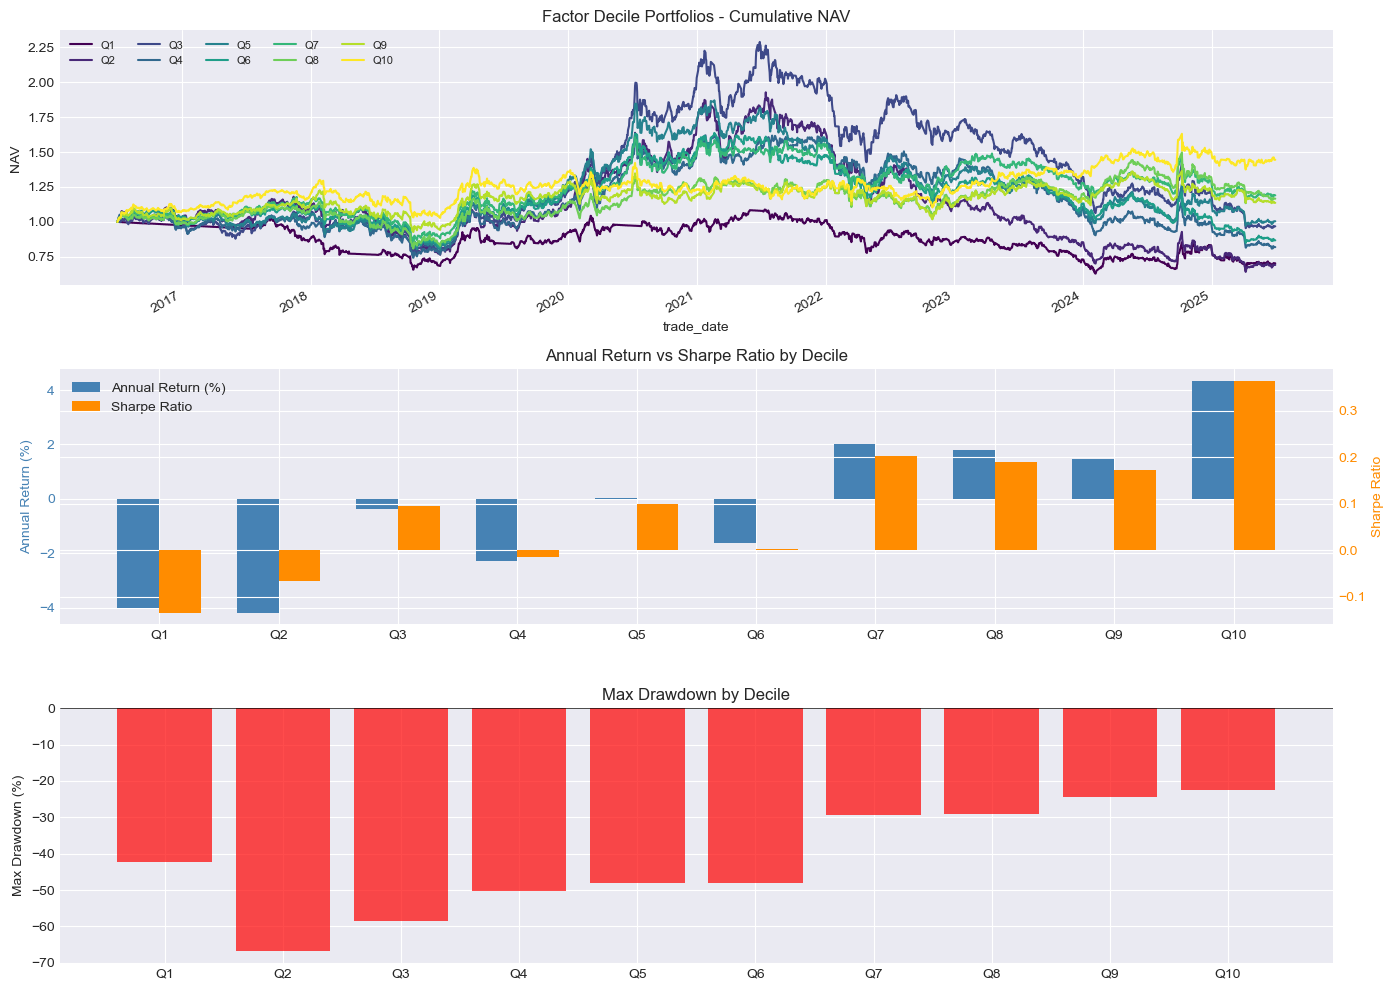


========== Performance Metrics ==========
    AnnualReturn    Sharpe MaxDrawdown
Q1     -0.039924 -0.133768   -0.422315
Q2     -0.041787 -0.066284   -0.667741
Q3     -0.003788  0.094432   -0.584644
Q4     -0.022817 -0.014566   -0.501501
Q5      0.000448  0.099983   -0.481279
Q6     -0.016292  0.003357   -0.481934
Q7      0.020272  0.202534   -0.294314
Q8      0.017864  0.189893   -0.292151
Q9      0.014836  0.172594   -0.244784
Q10     0.043361   0.36437   -0.224387

Spearman correlation between rank and annual return: 0.8788 (p-value: 0.0008)
Conclusion: Strong monotonicity, high factor group outperforms low group significantly.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ===================== Configuration =====================
CONFIG = {
    "START_DATE": "2016-07-01",
    "END_DATE": "2025-06-30",
    "REBALANCE_FREQ": 5,               # Rebalance every 5 trading days
    "N_QUANTILES": 10,                 # Deciles (10 groups)
    "TRANSACTION_FEE": 0.001,          # 0.1% transaction cost
    "PRICE_FILE": "data/eod_prices.parquet",
    "FACTOR_FILE": "data/dividend_factor.parquet",
    "FUND_FILE": "data/ref_data/ETF_hold_510300.SH.parquet",  # For constituent filtering
    "USE_WINSORIZE": False,
    "WINSORIZE_LIMITS": (0.01, 0.01),
    "STANDARDIZE_BY_INDUSTRY": False,
    "PRINT_STOCK_CODES": True,         # Print first stock code of each group at each rebalance
}

# ===================== Helper Functions =====================
def calc_metrics(returns_series, rf=0.0, periods_per_year=252):
    """Calculate annualized return, Sharpe ratio, and maximum drawdown"""
    if len(returns_series) == 0:
        return np.nan, np.nan, np.nan
    returns_series = returns_series.astype(float)
    cum_ret = (1 + returns_series).cumprod()
    total_return = cum_ret.iloc[-1] - 1
    years = len(returns_series) / periods_per_year
    annual_return = (1 + total_return) ** (1 / years) - 1 if years > 0 else 0
    excess_returns = returns_series - rf / periods_per_year
    sharpe = np.sqrt(periods_per_year) * excess_returns.mean() / excess_returns.std() if excess_returns.std() != 0 else 0
    cummax = cum_ret.cummax()
    drawdown = (cum_ret - cummax) / cummax
    max_drawdown = drawdown.min()
    return annual_return, sharpe, max_drawdown

def get_csi300_holdings(fund_df, trade_date):
    """Get valid CSI300 constituents on a given date from fund holdings"""
    if fund_df.empty:
        return None
    valid = fund_df[
        (fund_df['pos_start_date'] <= trade_date) &
        (fund_df['pos_end_date'] >= trade_date)
    ]
    return valid['stock_code'].unique()

def prepare_data(config):
    """Load and preprocess factor, price, and constituent data"""
    # Factor data
    factor = pd.read_parquet(config["FACTOR_FILE"])
    factor['trade_date'] = pd.to_datetime(factor['trade_date'])
    factor = factor.dropna(subset=['dynamic_div_yield', 'industry_name'])
    factor = factor[(factor['trade_date'] >= config["START_DATE"]) & 
                    (factor['trade_date'] <= config["END_DATE"])]

    # Price data
    price = pd.read_parquet(config["PRICE_FILE"])
    price['trade_date'] = pd.to_datetime(price['trade_date'])
    price_pivot = price.pivot(index='trade_date', columns='stock_code', values='adjusted_close')
    price_pivot = price_pivot.sort_index()
    price_pivot.index = pd.to_datetime(price_pivot.index)

    # Constituent filtering (CSI300)
    fund_df = pd.read_parquet(config["FUND_FILE"])
    if not fund_df.empty:
        fund_df = fund_df.rename(columns={'end_date': 'report_end_date'})
        fund_df['report_end_date'] = pd.to_datetime(fund_df['report_end_date'])
        def get_period(row):
            year = row['report_year']
            if row['report_type'] == '中报':
                start = pd.to_datetime(f'{year}-01-01')
                end = pd.to_datetime(f'{year}-06-30')
            elif row['report_type'] == '年报':
                start = pd.to_datetime(f'{year}-07-01')
                end = pd.to_datetime(f'{year}-12-31')
            else:
                start = end = row['report_end_date']
            return pd.Series([start, end], index=['pos_start_date', 'pos_end_date'])
        fund_df[['pos_start_date', 'pos_end_date']] = fund_df.apply(get_period, axis=1)
        holdings = fund_df[['stock_code', 'pos_start_date', 'pos_end_date']].drop_duplicates()
    else:
        holdings = pd.DataFrame()
    
    # Optional winsorization
    if config["USE_WINSORIZE"]:
        from scipy.stats.mstats import winsorize
        factor['dynamic_div_yield'] = winsorize(factor['dynamic_div_yield'].values,
                                                limits=config["WINSORIZE_LIMITS"])
    # Optional industry standardization
    if config["STANDARDIZE_BY_INDUSTRY"]:
        factor['factor_std'] = factor.groupby(['trade_date', 'industry_name'])['dynamic_div_yield'].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0)
        factor_col = 'factor_std'
    else:
        factor_col = 'dynamic_div_yield'
    
    return factor, price_pivot, holdings, factor_col

def quantile_backtest(config):
    """Decile portfolio backtest main function (exactly 10 groups)"""
    print("=" * 60)
    print("Factor Decile Portfolio Backtest (0~100% Quantiles, 10 groups)")
    print(f"Rebalance frequency: every {config['REBALANCE_FREQ']} trading days")
    print(f"Transaction cost: {config['TRANSACTION_FEE']*100:.1f}%")
    print("=" * 60)
    
    # 1. Load data
    factor, price_pivot, holdings, factor_col = prepare_data(config)
    
    # 2. Get all trading days
    all_dates = price_pivot.index
    mask = (all_dates >= pd.Timestamp(config["START_DATE"])) & (all_dates <= pd.Timestamp(config["END_DATE"]))
    all_dates = all_dates[mask]
    if len(all_dates) == 0:
        raise ValueError("No valid trading days in backtest period")
    
    # 3. Determine rebalance dates
    rebalance_dates = all_dates[::config["REBALANCE_FREQ"]].tolist()
    rebalance_dates = [d for d in rebalance_dates if d <= pd.Timestamp(config["END_DATE"])]
    
    # 4. Store daily returns for each quantile group
    n_quantiles = config["N_QUANTILES"]
    quantile_ret_dict = {q: {} for q in range(n_quantiles)}
    
    # 5. Event-driven backtest
    for i, current_date in enumerate(tqdm(rebalance_dates, desc="Backtesting")):
        next_date = rebalance_dates[i+1] if i+1 < len(rebalance_dates) else all_dates[-1]
        
        # Factor data on current rebalance date
        daily_factor = factor[factor['trade_date'] == current_date].copy()
        if daily_factor.empty:
            continue
        
        # Filter by CSI300 constituents
        if not holdings.empty:
            valid_stocks = get_csi300_holdings(holdings, current_date)
            if valid_stocks is not None and len(valid_stocks) > 0:
                daily_factor = daily_factor[daily_factor['stock_code'].isin(valid_stocks)]
        
        daily_factor = daily_factor.dropna(subset=[factor_col])
        if daily_factor.empty:
            continue
        
        # ---------- Quantile assignment (robust, exactly n_quantiles groups) ----------
        daily_factor = daily_factor.sort_values(factor_col, ascending=True)  # low -> high
        daily_factor['pct_rank'] = daily_factor[factor_col].rank(pct=True)
        daily_factor['quantile'] = (daily_factor['pct_rank'] * n_quantiles).clip(upper=n_quantiles-1).astype(int)
        groups = daily_factor.groupby('quantile')
        actual_groups = set(groups.groups.keys())
        
        # Trading days in current period
        period_dates = all_dates[(all_dates >= current_date) & (all_dates < next_date)]
        if len(period_dates) == 0:
            continue
        
        # For each quantile group, compute equally-weighted daily returns
        for q in range(n_quantiles):
            if q in actual_groups:
                group_stocks = groups.get_group(q)
                stock_list = group_stocks['stock_code'].tolist()
                if len(stock_list) == 0:
                    daily_returns = pd.Series(0, index=period_dates, dtype=float)
                else:
                    price_sub = price_pivot[stock_list].reindex(period_dates)
                    price_sub = price_sub.fillna(method='ffill')
                    ret_sub = price_sub.pct_change().fillna(0)
                    daily_returns = ret_sub.mean(axis=1).astype(float)
            else:
                daily_returns = pd.Series(0, index=period_dates, dtype=float)
            
            # Deduct transaction cost on rebalance day
            if config["TRANSACTION_FEE"] > 0 and len(daily_returns) > 0:
                daily_returns.iloc[0] -= config["TRANSACTION_FEE"]
            
            # Store returns
            for date, ret in daily_returns.items():
                quantile_ret_dict[q][date] = ret
    
    # 6. Build full time series for each quantile (fill missing with 0)
    quantile_series = {}
    for q in range(n_quantiles):
        s = pd.Series(quantile_ret_dict[q], dtype=float)
        s = s.reindex(all_dates, fill_value=0.0)
        quantile_series[q] = s
    
    # 7. Calculate performance metrics
    metrics_df = pd.DataFrame(index=[f"Q{i+1}" for i in range(n_quantiles)],
                              columns=["AnnualReturn", "Sharpe", "MaxDrawdown"])
    for q in range(n_quantiles):
        ret_series = quantile_series[q].dropna()
        if len(ret_series) == 0:
            continue
        ann_ret, sharpe, mdd = calc_metrics(ret_series)
        metrics_df.iloc[q] = [ann_ret, sharpe, mdd]
    
    # 8. Cumulative NAV
    nav_df = pd.DataFrame(index=all_dates)
    for q in range(n_quantiles):
        nav_df[f"Q{q+1}"] = (1 + quantile_series[q]).cumprod()
    
    # 9. Plotting (all English labels)
    plt.style.use('seaborn-v0_8-darkgrid')
    fig = plt.figure(figsize=(14, 10))
    
    # Subplot 1: Cumulative NAV
    ax1 = plt.subplot(3, 1, 1)
    nav_df.plot(ax=ax1, colormap='viridis', lw=1.5)
    ax1.set_title('Factor Decile Portfolios - Cumulative NAV', fontsize=12)
    ax1.set_ylabel('NAV')
    ax1.legend(loc='upper left', ncol=5, fontsize=8)
    
    # Subplot 2: Annual Return vs Sharpe Ratio (dual bar chart)
    ax2 = plt.subplot(3, 1, 2)
    x = np.arange(len(metrics_df))
    width = 0.35
    ann_ret_vals = metrics_df['AnnualReturn'].values * 100  # as percentage
    sharpe_vals = metrics_df['Sharpe'].values
    bars1 = ax2.bar(x - width/2, ann_ret_vals, width, label='Annual Return (%)', color='steelblue')
    ax2.set_ylabel('Annual Return (%)', color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue')
    ax3 = ax2.twinx()
    bars2 = ax3.bar(x + width/2, sharpe_vals, width, label='Sharpe Ratio', color='darkorange')
    ax3.set_ylabel('Sharpe Ratio', color='darkorange')
    ax3.tick_params(axis='y', labelcolor='darkorange')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"Q{i+1}" for i in range(len(metrics_df))])
    ax2.set_title('Annual Return vs Sharpe Ratio by Decile')
    ax2.legend([bars1, bars2], ['Annual Return (%)', 'Sharpe Ratio'], loc='upper left')
    
    # Subplot 3: Max Drawdown
    ax4 = plt.subplot(3, 1, 3)
    mdd_vals = metrics_df['MaxDrawdown'].values * 100
    colors = ['green' if x > -0.1 else 'red' for x in mdd_vals]
    ax4.bar(x, mdd_vals, color=colors, alpha=0.7)
    ax4.set_ylabel('Max Drawdown (%)')
    ax4.set_xticks(x)
    ax4.set_xticklabels([f"Q{i+1}" for i in range(len(metrics_df))])
    ax4.set_title('Max Drawdown by Decile')
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.savefig('factor_quantile_performance.png', dpi=200)
    plt.show()
    
    # 10. Print metrics table and monotonicity test
    print("\n========== Performance Metrics ==========")
    print(metrics_df.round(4))
    
    # Monotonicity test (Spearman correlation between rank and annual return)
    from scipy.stats import spearmanr
    rank = np.arange(1, len(metrics_df)+1)
    ann_ret = metrics_df['AnnualReturn'].values
    ann_ret = np.array([float(x) if not pd.isna(x) else np.nan for x in ann_ret])
    valid_mask = ~np.isnan(ann_ret)
    if valid_mask.sum() > 1:
        corr, pval = spearmanr(rank[valid_mask], ann_ret[valid_mask])
        print(f"\nSpearman correlation between rank and annual return: {corr:.4f} (p-value: {pval:.4f})")
        if corr > 0.5 and pval < 0.05:
            print("Conclusion: Strong monotonicity, high factor group outperforms low group significantly.")
        elif corr > 0:
            print("Conclusion: Weak monotonicity, further optimization may be needed.")
        else:
            print("Conclusion: No clear monotonicity or reverse pattern, factor ineffective.")
    else:
        print("Insufficient valid groups for monotonicity test.")
    
    return nav_df, metrics_df

# ===================== Run Backtest =====================
if __name__ == "__main__":
    nav, metrics = quantile_backtest(CONFIG)